In [218]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from src.data import get_data, save_data

In [219]:
df_base = get_data('df_clean')

Đã đọc thành công dữ liệu từ: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_clean


In [220]:
df_base.head()

,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos,holiday_name
Timestamp,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,51764.567568,0,5,1,1,1,1,52,1,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 01:00:00,66344.627687,1,5,1,1,1,1,52,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 02:00:00,65981.054883,2,5,1,1,1,1,52,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 03:00:00,66576.533566,3,5,1,1,1,1,52,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 04:00:00,64963.552675,4,5,1,1,1,1,52,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo


# Thử nghiệm lag, rolling

In [221]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.compose import TransformedTargetRegressor

# -------------------------------------------------------------------------
# BƯỚC 1: XÁC ĐỊNH TẬP BIẾN NGOẠI SINH (EXOGENOUS FEATURES)
# -------------------------------------------------------------------------
# Khai báo toàn bộ các cột tĩnh, lịch biểu, Fourier và thời tiết (nếu có)
# LƯU Ý: Tuyệt đối không để các biến Lags/Rolling của total_load ở đây
exo_features = [col for col in df_base.columns if col != 'total_load']

target = 'total_load'

# Đảm bảo index là DatetimeIndex và được sắp xếp chuẩn
df_base = df_base.sort_index()

# -------------------------------------------------------------------------
# BƯỚC 2: TÁCH TẬP DỮ LIỆU ĐỂ HUẤN LUYỆN "CỖ MÁY THỜI GIAN"
# -------------------------------------------------------------------------
# Tập Train: Giai đoạn hệ thống đã ổn định (2012 và 2013)
X_train_stable = df_base.loc['2012-01-01':'2013-12-31', exo_features]
y_train_stable = df_base.loc['2012-01-01':'2013-12-31', target]

# Tập Cần dự báo ngược (Hindcast): Toàn bộ năm 2011
X_backcast_2011 = df_base.loc['2011-01-01':'2011-12-31', exo_features]

# -------------------------------------------------------------------------
# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH BACKCASTING TỐI ƯU
# -------------------------------------------------------------------------
# Cấu hình LightGBM tập trung bắt ranh giới phi tuyến ngoại sinh
lgbm_core = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    colsample_bytree=0.8, # Chống Overfitting vào 1-2 biến chu kỳ
    random_state=42,
    n_jobs=-1
)

# Bọc Log-transform để xấp xỉ chuẩn xác các đỉnh mùa hè
backcast_model = TransformedTargetRegressor(
    regressor=lgbm_core,
    func=np.log1p,
    inverse_func=np.expm1
)

print("Đang huấn luyện cỗ máy thời gian tái tạo năm 2011...")
backcast_model.fit(X_train_stable, y_train_stable)

# -------------------------------------------------------------------------
# BƯỚC 4: TÁI TẠO LỊCH SỬ & HOÁN ĐỔI DỮ LIỆU
# -------------------------------------------------------------------------
# Xuất ra chuỗi tải điện tổng hợp cho năm 2011
y_synthetic_2011 = backcast_model.predict(X_backcast_2011)

# Tạo một bản sao dữ liệu mới để xây dựng Lags (tránh đụng chạm df_clean gốc)
df_2011 = df_base.copy()

# THAY THẾ HOÀN TOÀN tải điện thô 2011 bằng chuỗi tổng hợp sạch
df_2011.loc['2011-01-01':'2011-12-31', target] = y_synthetic_2011

print("Đã thay thế thành công dữ liệu 2011 bằng Synthetic Backcasting!")

Đang huấn luyện cỗ máy thời gian tái tạo năm 2011...
Đã thay thế thành công dữ liệu 2011 bằng Synthetic Backcasting!


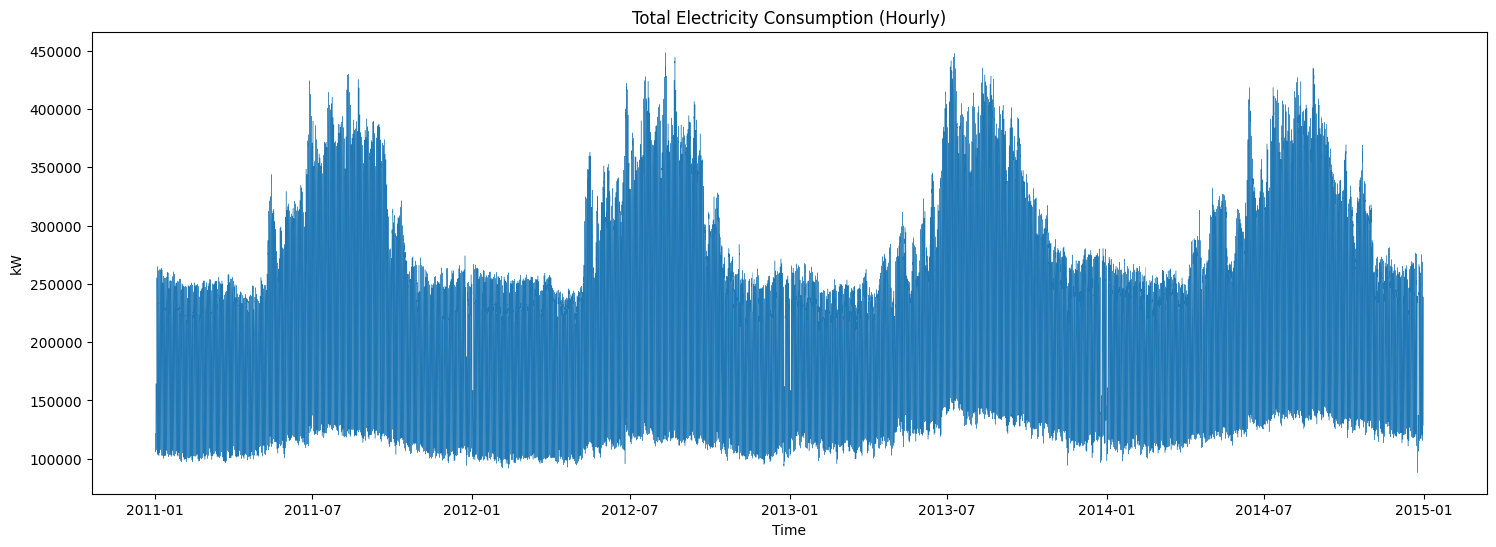

In [222]:
plt.figure(figsize=(18,6))
plt.plot(df_2011.index, df_2011["total_load"], linewidth=0.3)
plt.title("Total Electricity Consumption (Hourly)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

In [223]:
import pandas as pd

# Giả sử 'df' là DataFrame gốc, index là DatetimeIndex tần suất 1 giờ
df = df_2011.copy()
df = df[['total_load']].copy()  # Chỉ giữ cột total_load để tính rolling

# 1. TÍNH ROLLING TRÊN CHUỐI GỐC
df["r_mean_day"] = df["total_load"].rolling(24, min_periods=1).mean()
df["r_std_day"] = df["total_load"].rolling(24, min_periods=1).std().fillna(0)
df["r_mean_week"] = df["total_load"].rolling(168, min_periods=1).mean()
df["r_std_week"] = df["total_load"].rolling(168, min_periods=1).std().fillna(0)
df["r_mean_month"] = df["total_load"].rolling(672, min_periods=1).mean()
df["r_std_month"] = df["total_load"].rolling(672, min_periods=1).std().fillna(0)

# 2. TẠO KEYS ÁNH XẠ ĐỒNG BỘ THEO CHUẨN ISO
iso_cols = df.index.isocalendar()
df["iso_year"] = iso_cols["year"]
df["iso_week"] = iso_cols["week"]
df["dayofweek"] = df.index.dayofweek
df["hour"] = df.index.hour

keys = ["iso_year", "iso_week", "dayofweek", "hour"]
roll_cols = [
    "total_load",
    "r_mean_day",
    "r_std_day",
    "r_mean_week",
    "r_std_week",
    "r_mean_month",
    "r_std_month",
]

df_past = df[keys + roll_cols].copy()
df_past["target_year"] = df_past["iso_year"] + 1

# 3. MERGE LẤY LAG 1 NĂM (Tránh dùng set_index khi merge để an toàn)
df_merged = pd.merge(
    df.reset_index(),
    df_past,
    how="left",
    left_on=keys,
    right_on=["target_year", "iso_week", "dayofweek", "hour"],
    suffixes=("", "_past"),
)

# Gán trực tiếp qua mảng .values để tốc độ nhanh nhất và bỏ qua rào cản gán Index
df["lag_1y_base"] = df_merged["total_load_past"].ffill(limit=1).values
df["rolling_mean_1y_day"] = df_merged["r_mean_day_past"].ffill(limit=1).values
df["rolling_std_1y_day"] = df_merged["r_std_day_past"].ffill(limit=1).values
df["rolling_mean_1y_week"] = df_merged["r_mean_week_past"].ffill(limit=1).values
df["rolling_std_1y_week"] = df_merged["r_std_week_past"].ffill(limit=1).values
df["rolling_mean_1y_month"] = (
    df_merged["r_mean_month_past"].ffill(limit=1).values
)
df["rolling_std_1y_month"] = df_merged["r_std_month_past"].ffill(limit=1).values

# 4. DỌN DẸP VÀ CHIA TẬP TRAIN / TEST
cols_to_drop = keys + roll_cols[1:]
df = df.drop(columns=cols_to_drop)

df_final = df.loc["2012-01-28":].copy()
df_final.head()

,total_load,lag_1y_base,rolling_mean_1y_day,rolling_std_1y_day,rolling_mean_1y_week,rolling_std_1y_week,rolling_mean_1y_month,rolling_std_1y_month
Timestamp,,,,,,,,
2012-01-28 00:00:00,140768.241446,141712.314795,189112.266018,54228.406074,186801.532764,53037.211196,186258.087845,54160.175959
2012-01-28 01:00:00,117639.433304,118901.037687,189202.196881,54104.821188,186781.298061,53062.609325,186266.526224,54149.221637
2012-01-28 02:00:00,111940.451150,110743.382074,189201.275969,54106.214466,186756.475245,53097.394537,186266.526315,54149.221511
2012-01-28 03:00:00,103170.529666,102809.733504,189035.314691,54375.417063,186734.366882,53131.763427,186258.695452,54160.925805
2012-01-28 04:00:00,99374.780029,99802.295376,188806.879762,54752.763319,186716.551836,53160.570653,186249.189253,54175.558780


In [224]:
# 1. Loại bỏ cột 'total_load' ở df_final (vì df_base đã có rồi)
# Thao tác này giúp tránh việc bị tạo ra các cột total_load_x, total_load_y
df_final_features = df_final.drop(columns=['total_load'])

# 2. Thực hiện Inner Join dựa trên Index (Timestamp)
# how='inner' sẽ tự động cắt dữ liệu df_base để khớp với mốc 28/01/2012 của df_final
df_model = df_base.join(df_final_features, how='inner')

# 3. Kiểm tra lại danh sách cột cuối cùng
print(f"Tổng số cột sau khi gộp: {len(df_model.columns)}")
print("Danh sách các cột mới đã thêm:", [c for c in df_model.columns if '1y' in c])

# 4. Chia tập Train/Test để bắt đầu huấn luyện
df_train = df_model.loc["2012-01-28":"2013-12-31"]
df_test = df_model.loc["2014-01-01":"2014-12-31"]

Tổng số cột sau khi gộp: 25
Danh sách các cột mới đã thêm: ['lag_1y_base', 'rolling_mean_1y_day', 'rolling_std_1y_day', 'rolling_mean_1y_week', 'rolling_std_1y_week', 'rolling_mean_1y_month', 'rolling_std_1y_month']


In [225]:
df_model.head()

,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,...,year_sin,year_cos,holiday_name,lag_1y_base,rolling_mean_1y_day,rolling_std_1y_day,rolling_mean_1y_week,rolling_std_1y_week,rolling_mean_1y_month,rolling_std_1y_month
Timestamp,,,,,,,,,,,,,,,,,,,,,
2012-01-28 00:00:00,140768.241446,0,5,1,1,28,28,4,1,0.000000,...,0.447945,0.894061,None,141712.314795,189112.266018,54228.406074,186801.532764,53037.211196,186258.087845,54160.175959
2012-01-28 01:00:00,117639.433304,1,5,1,1,28,28,4,1,0.258819,...,0.447945,0.894061,None,118901.037687,189202.196881,54104.821188,186781.298061,53062.609325,186266.526224,54149.221637
2012-01-28 02:00:00,111940.451150,2,5,1,1,28,28,4,1,0.500000,...,0.447945,0.894061,None,110743.382074,189201.275969,54106.214466,186756.475245,53097.394537,186266.526315,54149.221511
2012-01-28 03:00:00,103170.529666,3,5,1,1,28,28,4,1,0.707107,...,0.447945,0.894061,None,102809.733504,189035.314691,54375.417063,186734.366882,53131.763427,186258.695452,54160.925805
2012-01-28 04:00:00,99374.780029,4,5,1,1,28,28,4,1,0.866025,...,0.447945,0.894061,None,99802.295376,188806.879762,54752.763319,186716.551836,53160.570653,186249.189253,54175.558780


In [226]:
save_data(df_model, 'df_all_features')

Đã lưu thành công tại: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_all_features


In [227]:
target = 'total_load'
features = [col for col in df_model.columns if col not in [target, 'rolling_std_1y_day', 'rolling_std_1y_week', 'rolling_std_1y_month', 'quarter', 'week_of_year', 'month', 'day_sin', 'day_cos', 'year_sin', 'year_cos', 'rolling_mean_1y_day']]

In [228]:
from src.baseline import lightgbm_model

val, model, metrics = lightgbm_model(df_model, target, features)

print("KẾT QUẢ LIGHTGBM MODEL")
print("-" * 40)
print(f"MAE  : {metrics['MAE']:,.2f} kWh")
print(f"RMSE : {metrics['RMSE']:,.2f} kWh")
print(f"MAPE : {metrics['MAPE']:.2f} %")

KẾT QUẢ LIGHTGBM MODEL
----------------------------------------
MAE  : 13,344.87 kWh
RMSE : 19,773.78 kWh
MAPE : 5.73 %


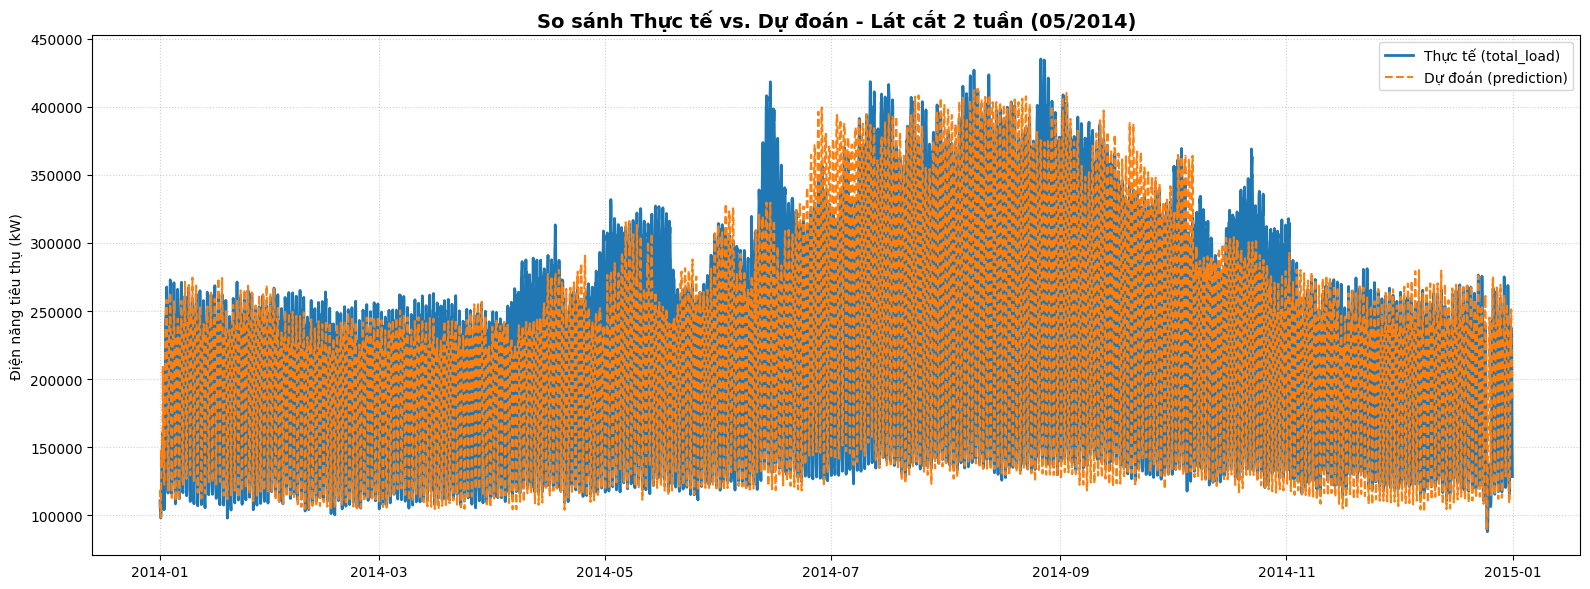

In [229]:
val_slice = val.loc["2014-01-01":"2014-12-31"]

plt.figure(figsize=(16, 6))
plt.plot(val_slice.index, val_slice["total_load"], label="Thực tế (total_load)", linewidth=2)
plt.plot(val_slice.index, val_slice["prediction"], label="Dự đoán (prediction)", linewidth=1.5, linestyle="--")

plt.title("So sánh Thực tế vs. Dự đoán - Lát cắt 2 tuần (05/2014)", fontsize=14, fontweight="bold")
plt.ylabel("Điện năng tiêu thụ (kW)")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

--- TOP 40 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---
              Feature  Importance
          day_of_year         610
 rolling_mean_1y_week         566
rolling_mean_1y_month         564
          lag_1y_base         418
         day_of_month         248
                 hour         177
          day_of_week         147
             hour_sin          62
         holiday_name          58
             hour_cos          55
            month_cos          52
            month_sin          43
           is_weekend           0


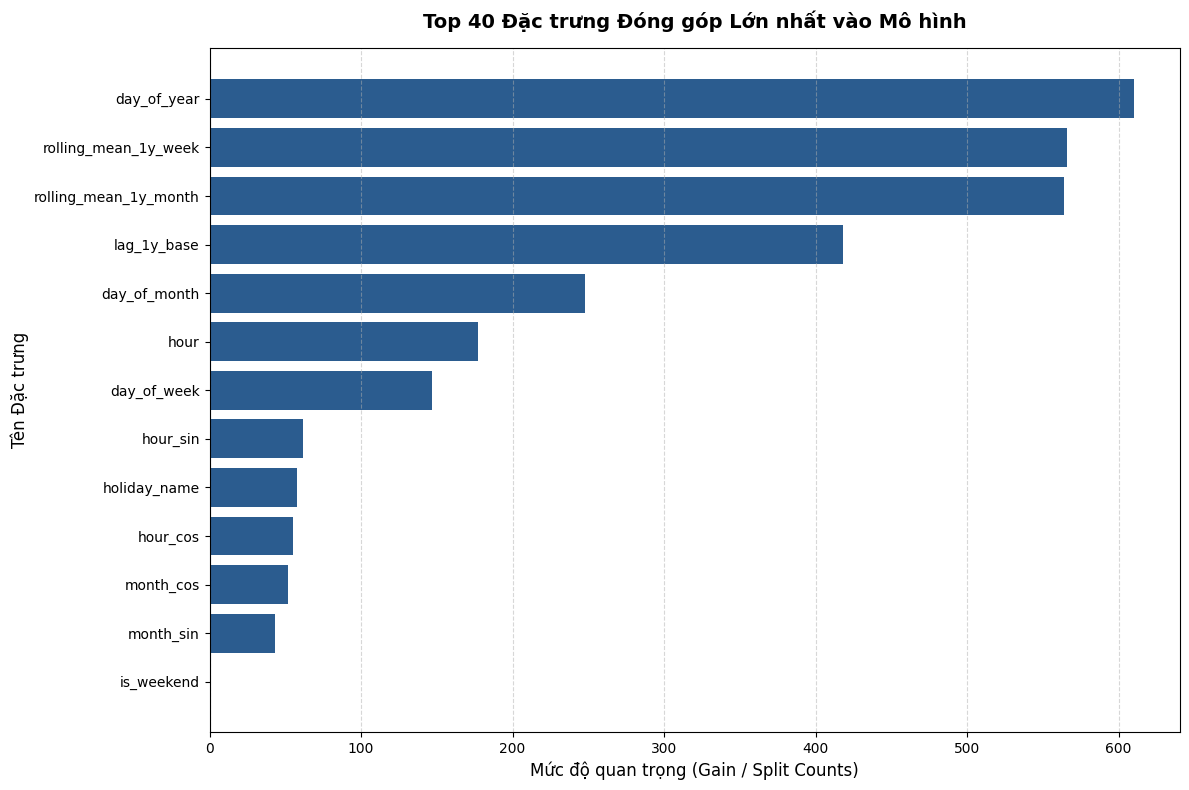

In [230]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Giả sử 'model' là mô hình bạn đã huấn luyện (model.fit(X_train, y_train))
# 'X_train' là ma trận chứa các features của bạn

X_train = df_train[features]

# ==============================================================================
# 1. LẤY GIÁ TRỊ ĐỘ QUAN TRỌNG (DÙNG CHO LIGHTGBM / XGBOOST / RANDOM FOREST)
# ==============================================================================
# Tùy thuộc vào thư viện, ta trích xuất mảng importance
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
elif hasattr(model, "booster_"):  # Dành riêng cho LightGBM native API
    importances = model.feature_importance(importance_type="gain")
else:
    raise ValueError("Mô hình không hỗ trợ trích xuất feature importance trực tiếp.")

# Tạo DataFrame ánh xạ Tên biến và Độ quan trọng
feat_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sắp xếp giảm dần để lấy Top
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Lấy Top 15 Features quan trọng nhất
top_n = 40
top_features = feat_imp_df.head(top_n)

print(f"--- TOP {top_n} ĐẶC TRƯNG QUAN TRỌNG NHẤT ---")
print(top_features.to_string(index=False))

# ==============================================================================
# 2. VẼ BIỂU ĐỒ TRỰC QUAN (HORIZONTAL BAR CHART)
# ==============================================================================
plt.figure(figsize=(12, 8))
# Vẽ biểu đồ thanh ngang, lật ngược thứ tự để biến quan trọng nhất nằm trên cùng
plt.barh(
    top_features["Feature"][::-1], 
    top_features["Importance"][::-1], 
    color="#2b5c8f", 
    edgecolor="none"
)

plt.title(f"Top {top_n} Đặc trưng Đóng góp Lớn nhất vào Mô hình", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mức độ quan trọng (Gain / Split Counts)", fontsize=12)
plt.ylabel("Tên Đặc trưng", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. LƯU DANH SÁCH TOP FEATURES ĐỂ DÙNG LẠI (TÙY CHỌN)
# ==============================================================================
# Bạn có thể dùng danh sách này để lọc lại tập X, bỏ bớt các biến rác
best_feature_names = top_features["Feature"].tolist()
# X_train_optimized = X_train[best_feature_names]

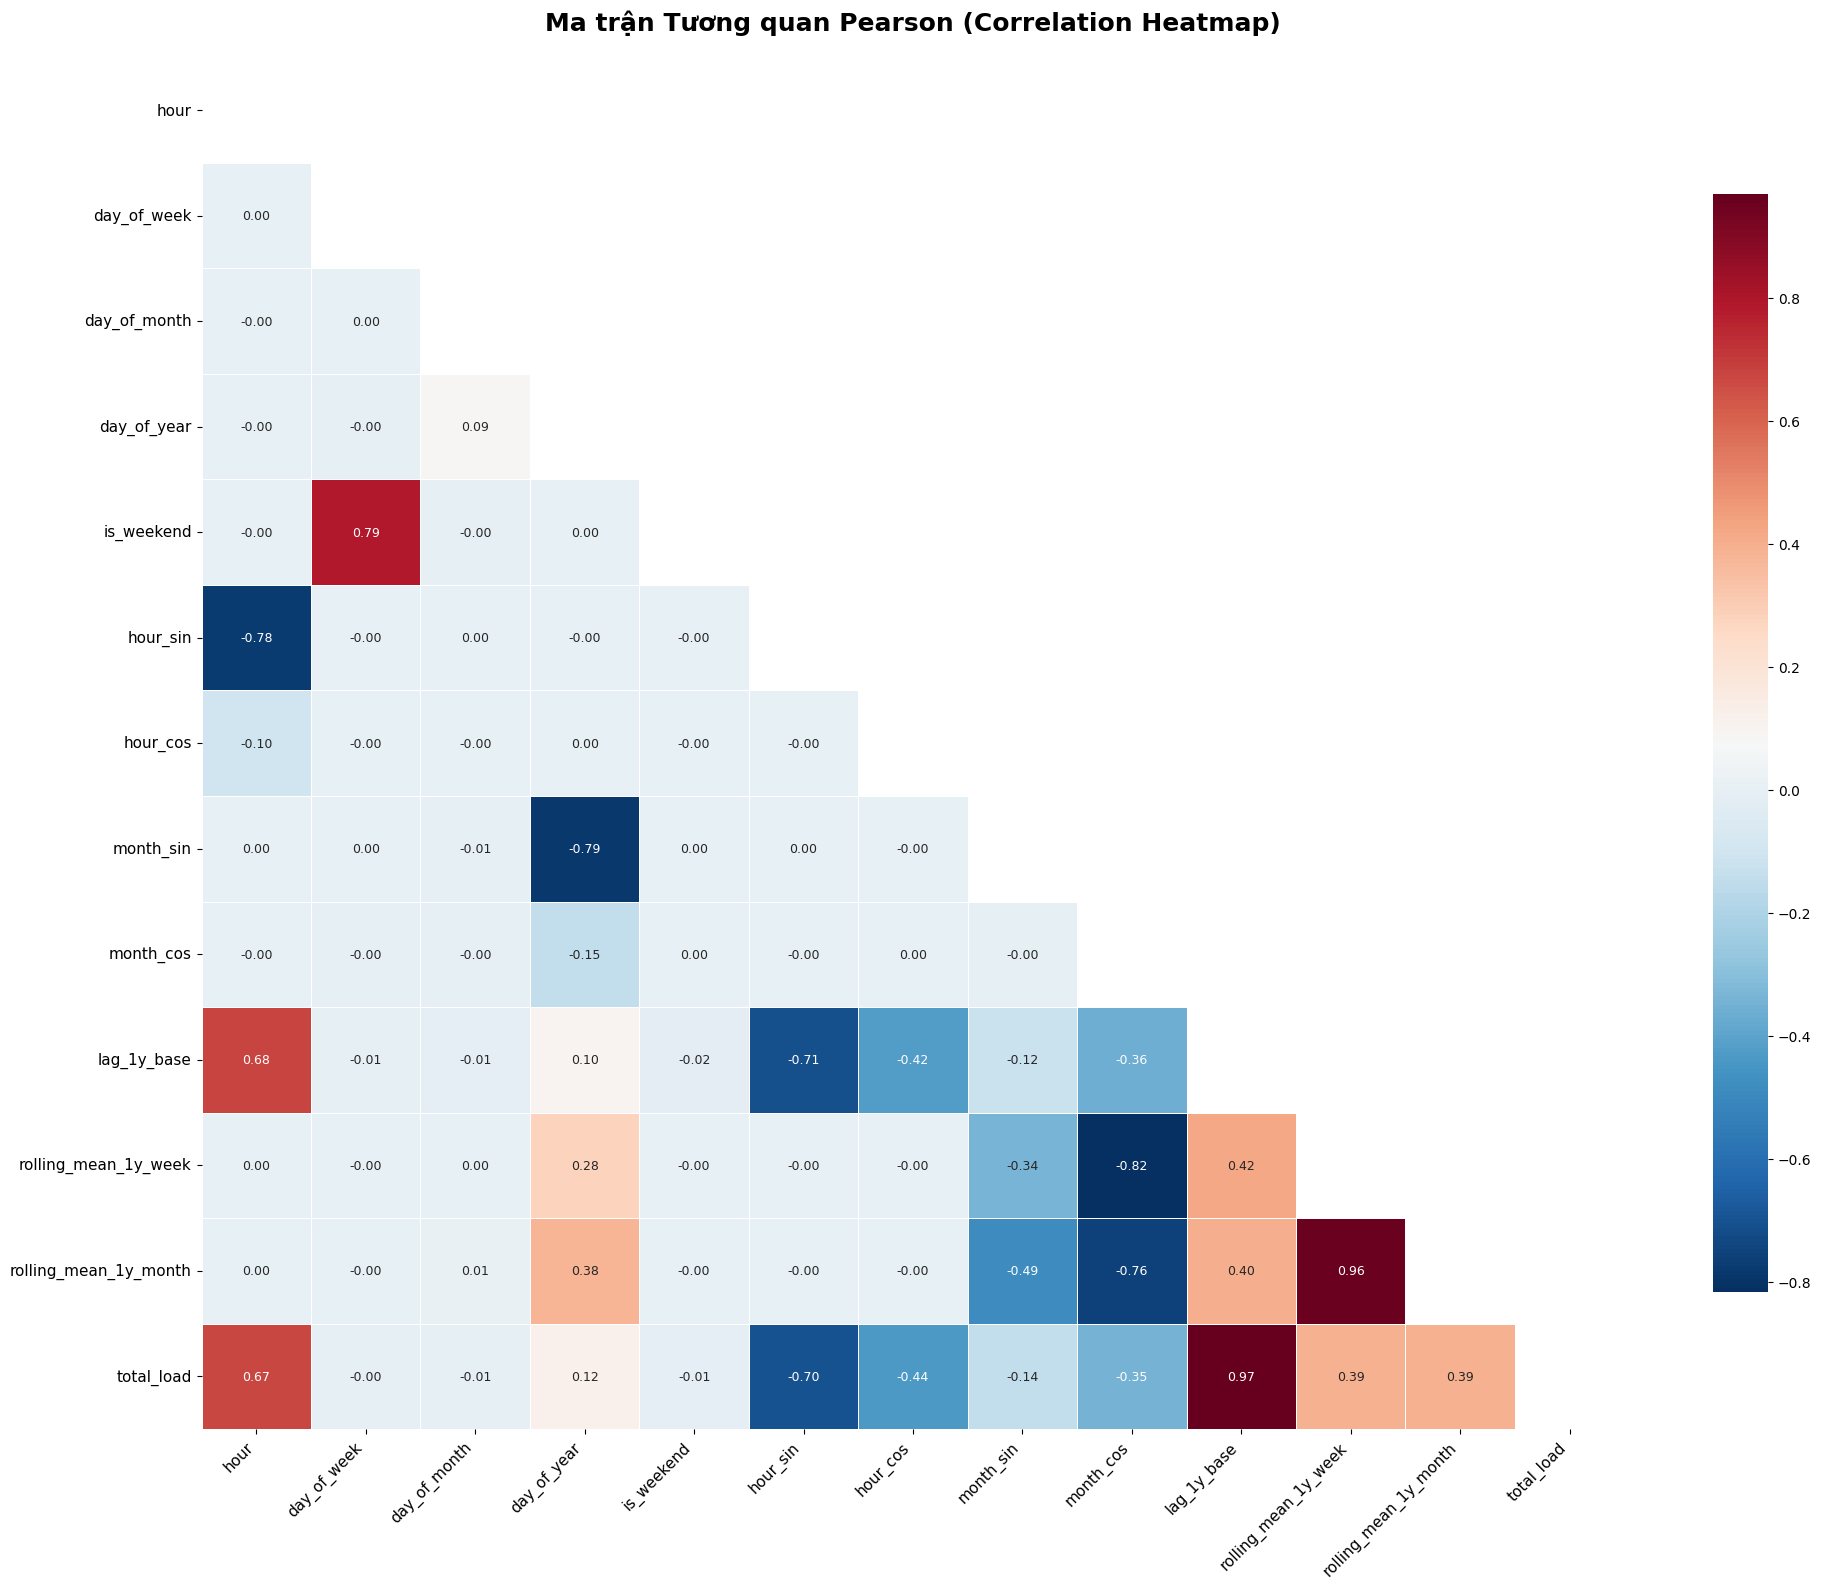

In [231]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Giả sử 'df_model' là tập dữ liệu cuối cùng của bạn đã gộp đủ features
# Lọc ra các cột dạng số (loại bỏ biến category như 'holiday_name')
df_heatmap = df_model.copy()
df_heatmap = df_heatmap[features + [target]]  # Chỉ giữ cột features và target để tránh rối loạn
df_numeric = df_heatmap.select_dtypes(include=[np.number])

# 1. Tính toán ma trận tương quan (Pearson Correlation)
corr = df_numeric.corr()

# 2. Tạo mặt nạ (mask) để ẩn nửa trên tam giác (tránh trùng lặp thông tin)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Thiết lập kích thước biểu đồ (đủ lớn cho hơn 20 features)
plt.figure(figsize=(20, 16))

# 4. Vẽ Heatmap bằng Seaborn
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",  # Thang màu Xanh (đồng biến) - Đỏ (nghịch biến)
    annot=True,     # Hiển thị số
    fmt=".2f",      # Làm tròn 2 chữ số thập phân
    annot_kws={"size": 9},  # Cỡ chữ số nhỏ lại để không lấn viền
    linewidths=0.5, # Đường kẻ phân cách các ô
    cbar_kws={"shrink": 0.8}, # Thu nhỏ thanh chú giải màu
)

plt.title("Ma trận Tương quan Pearson (Correlation Heatmap)", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

In [232]:
save_data(df_heatmap, 'df_best_features')

Đã lưu thành công tại: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_best_features
